1
60s
2
5min
3
30min
4
1h
5
5h
6
10h


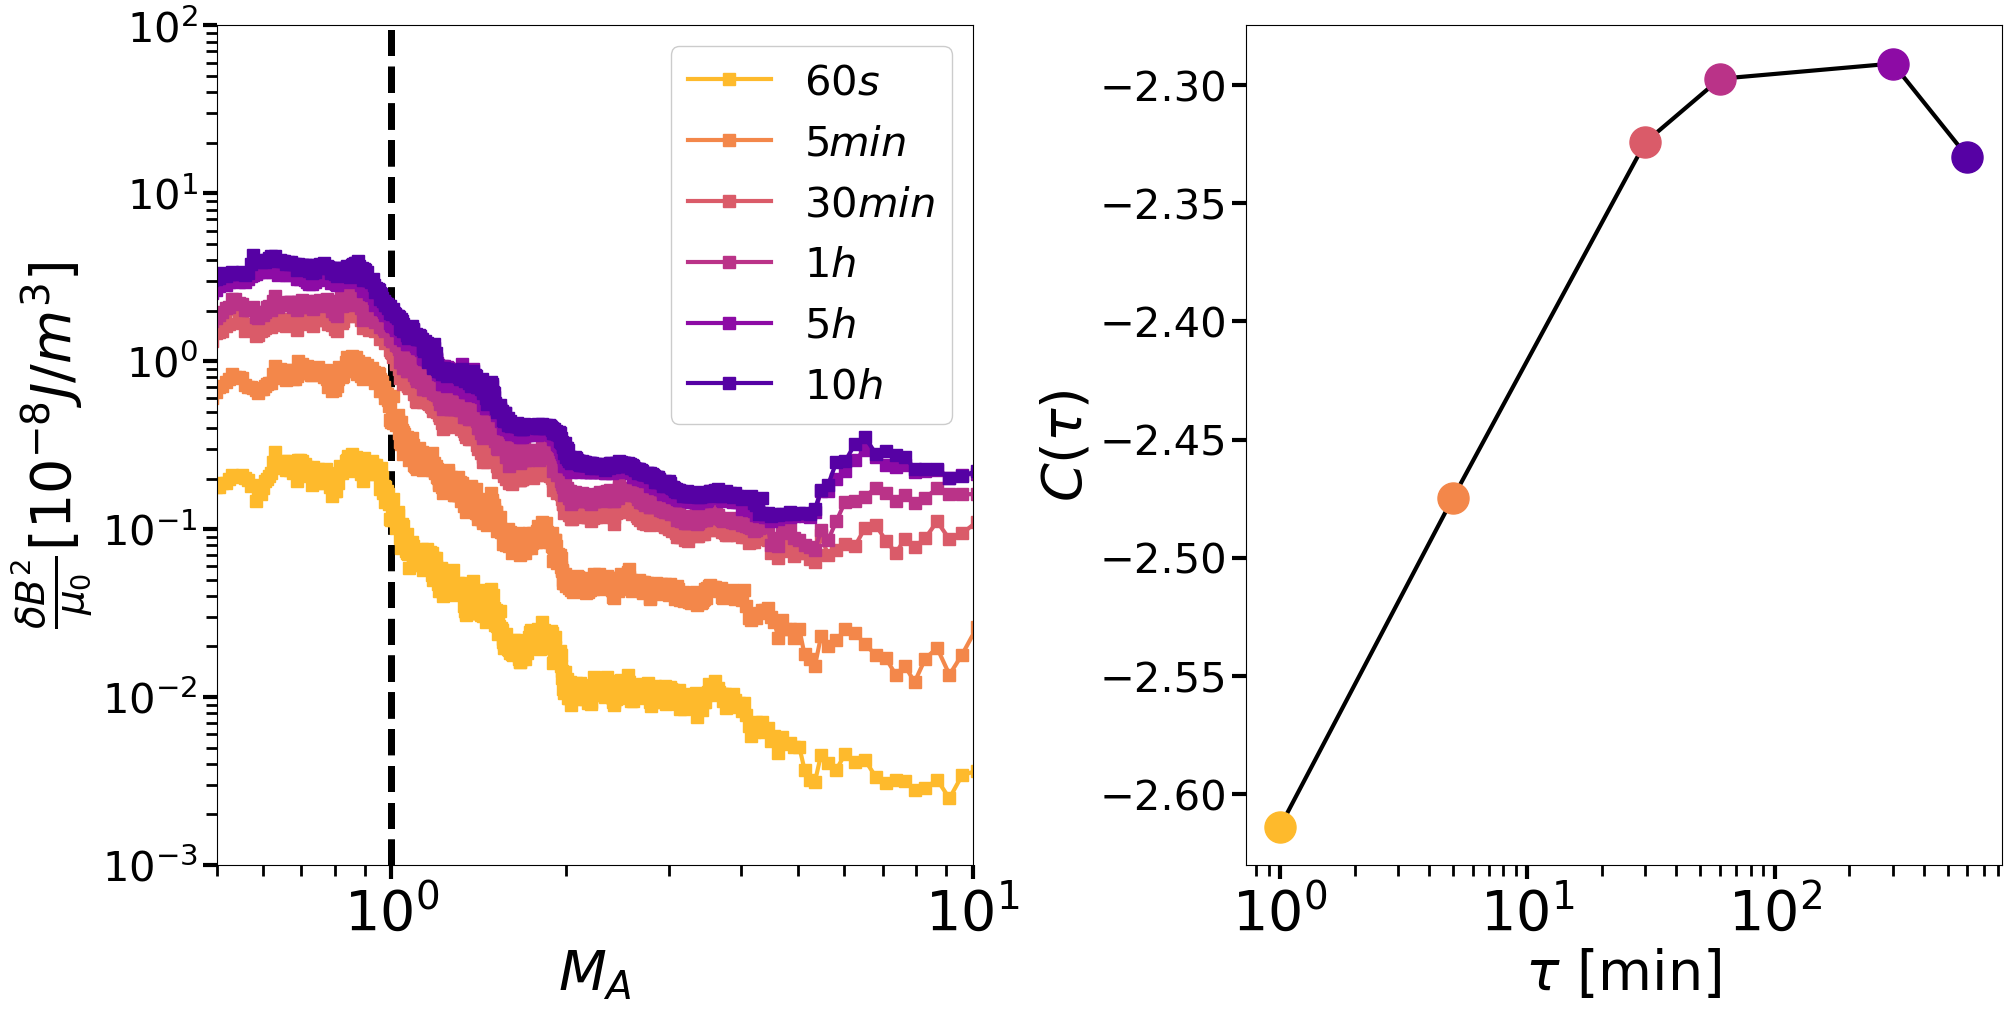

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import importlib
from scipy.stats import gaussian_kde, multivariate_normal
import scipy.constants as c
import encs as E
importlib.reload(E)


plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 30,
    'axes.labelsize': 40,
    'xtick.labelsize': 40,
    'xtick.major.pad': 5,
    'xtick.major.size':    3.5,
    'xtick.minor.size':    2,
    'ytick.labelsize': 30,
    'legend.fontsize': 30,
    'legend.title_fontsize' : 30,
    'figure.titlesize': 18,
    'figure.labelsize': 40,
    'xtick.major.size':    10,
    'xtick.minor.size':    8,
    'ytick.major.size':    10,
    'ytick.minor.size':    8,
    'xtick.major.width':   3,
    'xtick.minor.width':   2,
    'ytick.major.width':   3,
    'ytick.minor.width':   2,
    'pdf.compression': 9
})

# mean_win = 60

figsave = f'fig/dB_MA_fits.png'

zline = 0.5
MAline = 1

# xlim0 = [4e-1, 1e1]
xlim0 = [5e-1, 1e1]
ylim0 = [1e-3, 1e2]
# ylim0 = [1e-3, 1]



R = True

# enc_range=range(8, 18)
# df = E.load_all_encounters(enc_range, res=10, avg = 60)
# df['MA'] = E.M_A(df)
# df['R'] = E.load_R(df.index, 60)
tau = np.array([60, 300, 1800, 3600, 18000, 36000]) / 60

# colors = {
#     tau[0]: 'blue',
#     tau[1]: 'orange',
#     tau[2]: 'brown',
#     tau[3]: 'green',
#     tau[4]: 'black',
#     tau[5]: 'purple'
# }

# cols = {
#     '60s':  'blue',
#     '5min': 'orange',
#     '30min':'brown',
#     '1h':   'green',
#     '5h':   'black',
#     '10h':  'purple',
# }

cadences = ['60s', '5min', '30min', '1h', '5h', '10h']

cmap = plt.get_cmap('plasma_r')  # or 'plasma', 'magma', 'cividis', 'turbo'
vals = np.linspace(0.15, 0.85, len(cadences))

cols = {
    cadence: cmap(v)
    for cadence, v in zip(cadences, vals)
}


tau = np.array([60, 300, 1800, 3600, 18000, 36000]) / 60

colors = {
    t: cmap(v)
    for t, v in zip(tau, vals)
}



slopes = np.array([])
yint = np.array([])
# winds = ['30s', '10min']
# cols = ['tab:red', 'tab:blue']
# fit = [1, 5.5]
fig, axes = plt.subplots(1, 2, figsize=(20, 10), layout = 'constrained')
i = 0
for mean_window, c in cols.items():
    R = True
    enc_range = np.arange(8,20)
    df10 = E.load_all_encounters(enc_range, res = 10)
    df10 = df10[(df10['n'] > 0) & (df10['n'] < 1e15)]
    
    ma = E.M_A(df10)
    
    # df_enc = E.load_all_encounters(enc_range, res=10).dropna()
    # df_avg = df_enc.rolling(mean_window, center = True).mean()
    # df_avg['MA'] = E.M_A(df_avg)
    # ma = df_avg['MA']
    df10['Z'] = E.Z(df10)

    df10[['dBR', 'dBT', 'dBN', 'dB']] = E.dB_comp(df10, avg = mean_window, norm = True)
    n = 0
    bins= E.bin_average(ma, df10['dB'], N = 1000)
    # if mean_window in plots:
    axes[n].errorbar(bins.x_center[1:-1], bins.y_median[1:-1], color=c, marker='s', ms=8, lw=3, label = rf'${mean_window}$')
    

    axes[n].axvline(MAline, c='black', ls='dashed', lw=5)
    axes[n].set_yscale('log')
    axes[n].set_xscale('log')
    
    
    x = bins.x_center[1:-1]
    y = bins.y_median[1:-1]

    # remove invalid values
    mask = (x > 0) & (y > 0)

    x = x[mask]
    y = y[mask]

    logx = np.log10(x)
    logy = np.log10(y)

    fitmask = (x > 0.8) & (x < 3)

    coef = np.polyfit(logx[fitmask], logy[fitmask], 1)

    slope = coef[0]
    intercept = coef[1]
    
    xfit = np.logspace(np.log10(0.95), np.log10(3), 500)
    yfit = 10**intercept * xfit**slope
    
    # if mean_window in plots:

    # axes[0].plot(
    #     xfit,
    #     yfit,
    #     color=c,
    #     lw=4,
    #     ls = 'dashed'
    #     )
    
    slopes = np.append(slopes, slope)
    yint = np.append(yint, intercept)
    

    
    
    # xfit = np.linspace(5e-2, 2e1, 1000)
    # yfit = f * (1/(xfit * (xfit + 1)**2))


    # axes[i].plot(xfit, yfit, c = 'gold', lw = 6, ls = 'dashed', label = f'{f}'r'$\times [M_A(M_A + 1)^2]^{-1}$')
    

    
    i = i+1
    print(i)
    print(mean_window)
    
axes[n].set_ylabel(r'$\frac{\delta B^2}{\mu_0} [10^{-8} J/m^3]$')
axes[n].set_xlabel(r'$M_A$')
axes[n].legend(loc = 'upper right', framealpha = 1)
axes[n].set_ylim(ylim0[0],ylim0[1])
axes[n].set_xlim(xlim0[0],xlim0[1])

n = 1


# axes[n].plot(tau, slopes, lw=3, color='black')

axes[n].plot(
    tau, slopes,
    marker='o',
    markersize=18,
    lw=3,
    color='black'
)

for t, s in zip(tau, slopes):
    axes[n].scatter(t, s, s=500, color=colors[t], zorder=3)


# axes[n].tick_params(axis='x', labelsize=20)
# axins.plot(tau, 10**yint, marker='x', lw = 3, c = 'blue')
# axes[n].set_yscale('log')
axes[n].set_xscale('log')
axes[n].set_xlabel(r'$\tau$ [min]')
axes[n].set_ylabel(r'$C(\tau)$')


fig.savefig(figsave, dpi = 300)
# fig.clear()



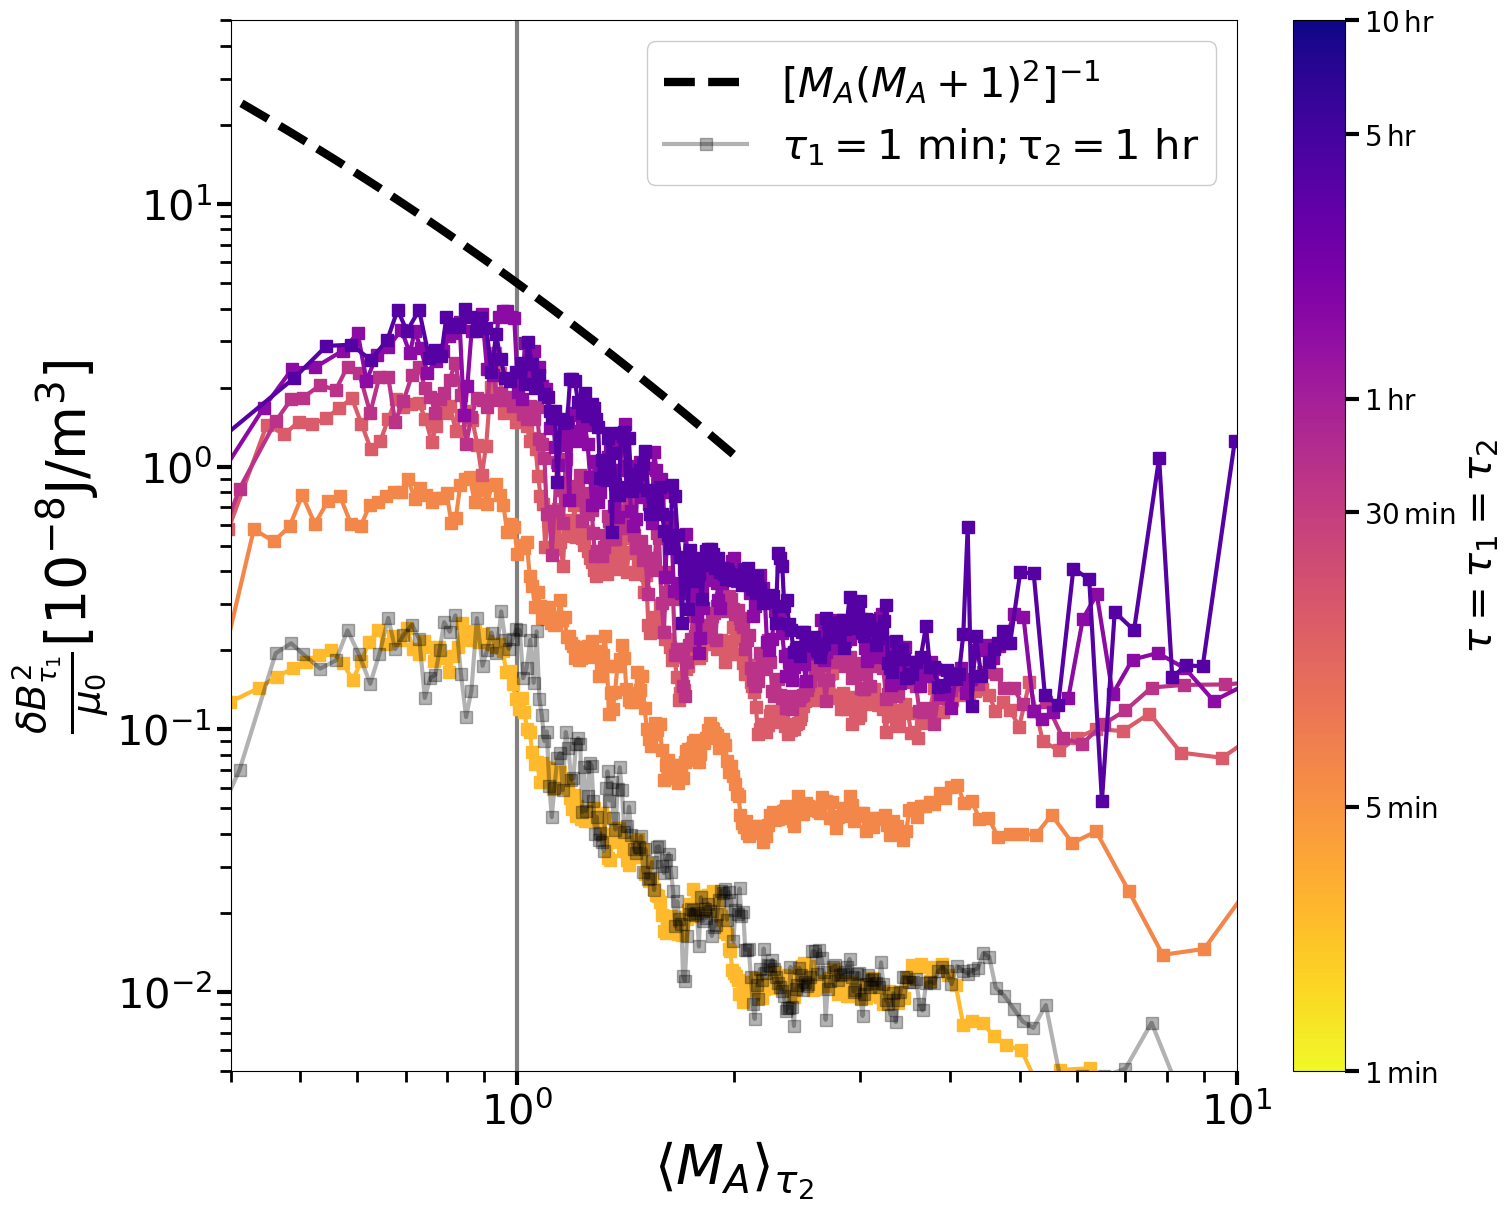

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import importlib
from scipy.stats import gaussian_kde, multivariate_normal
import scipy.constants as c
import encs as E
importlib.reload(E)


plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 30,
    'axes.labelsize': 40,
    'xtick.labelsize': 30,
    'xtick.major.pad': 5,
    'xtick.major.size':    3.5,
    'xtick.minor.size':    2,
    'ytick.labelsize': 30,
    'legend.fontsize': 30,
    'legend.title_fontsize' : 30,
    'figure.titlesize': 18,
    'figure.labelsize': 40,
    'xtick.major.size':    10,
    'xtick.minor.size':    8,
    'ytick.major.size':    10,
    'ytick.minor.size':    8,
    'xtick.major.width':   3,
    'xtick.minor.width':   2,
    'ytick.major.width':   3,
    'ytick.minor.width':   2,
    'pdf.compression': 9
})

# mean_win = 60

figsave = f'fig/dB_MA_fit.png'

zline = 0.5
MAline = 1

# xlim0 = [4e-1, 1e1]
xlim0 = [4e-1, 1e1]
ylim0 = [5e-3, 5e1]
# ylim0 = [1e-3, 1]



R = True

# enc_range=range(8, 18)
# df = E.load_all_encounters(enc_range, res=10, avg = 60)
# df['MA'] = E.M_A(df)
# df['R'] = E.load_R(df.index, 60)
tau = np.array([60, 300, 1800, 3600, 18000, 36000]) / 60

# colors = {
#     tau[0]: 'blue',
#     tau[1]: 'orange',
#     tau[2]: 'brown',
#     tau[3]: 'green',
#     tau[4]: 'black',
#     tau[5]: 'purple'
# }

# cols = {
#     '60s':  'blue',
#     '5min': 'orange',
#     '30min':'brown',
#     '1h':   'green',
#     '5h':   'black',
#     '10h':  'purple',
# }

cadences = ['1min', '5min', '30min', '1h', '5h', '10h']
cad_lab = [r'$1\,\rm{min}$', r'$5\,\rm{min}$', r'$30\,\rm{min}$', r'$1\,\rm{hr}$', r'$5\,\rm{hr}$', r'$10\,\rm{hr}$']


tau_min = np.array([1, 5, 30, 60, 300, 600])  # minutes

cad_tau = {
    cadence: t
    for cadence, t in zip(cadences, tau_min)
}
# log color normalization is best because tau spans 1 min to 600 min
norm = mcolors.LogNorm(vmin=tau_min.min(), vmax=tau_min.max())
cmap = plt.get_cmap('plasma_r')  # or 'plasma', 'magma', 'cividis', 'turbo'
vals = np.linspace(0.15, 0.85, len(cadences))

cols = {
    cadence: cmap(v)
    for cadence, v in zip(cadences, vals)
}

tau = np.array([60, 300, 1800, 3600, 18000, 36000]) / 60

colors = {
    t: cmap(v)
    for t, v in zip(tau, vals)
}

xfit = np.linspace(0.1, 2, 1000)
yfit = 2e1 * (1/(xfit * (xfit + 1)**2))



slopes = np.array([])
yint = np.array([])
# winds = ['30s', '10min']
# cols = ['tab:red', 'tab:blue']
# fit = [1, 5.5]
fig, axes = plt.subplots(1, 1, figsize=(15,12), layout = 'constrained')

mean_window = '60s'
R = True
enc_range = np.arange(8,20)
df10 = E.load_all_encounters(enc_range, res = 10)
df10 = df10[(df10['n'] > 0) & (df10['n'] < 1e15)]

df_enc = E.load_all_encounters(enc_range, res=10).dropna()
df_avg = df_enc.rolling('1h', center = True).mean()
df_avg['MA'] = E.M_A(df_avg)
ma = df_avg['MA']
df10['Z'] = E.Z(df10)

df10[['dBR', 'dBT', 'dBN', 'dB']] = E.dB_comp(df10, avg = mean_window, norm = True)
bins= E.bin_average(ma, df10['dB'], N = 3000)

axes.errorbar(bins.x_center[1:-1], bins.y_median[1:-1], color='black', marker='s', ms=8, lw=3, label = r'$\tau_1 = 1 \ \rm{min}; \tau_2 = 1 \ \rm{hr}$', alpha = 0.3, zorder = 10)

i = 0
for mean_window, v in zip(cadences,vals):
    c = cmap(v)
    R = True
    enc_range = np.arange(8,20)
    df10 = E.load_all_encounters(enc_range, res = 10)
    df10 = df10[(df10['n'] > 0) & (df10['n'] < 1e15)]
    
    
    df_enc = E.load_all_encounters(enc_range, res=10).dropna()
    df_avg = df_enc.rolling(mean_window, center = True).mean()
    df_avg['MA'] = E.M_A(df_avg)
    ma = df_avg['MA']
    df10['Z'] = E.Z(df10)

    df10[['dBR', 'dBT', 'dBN', 'dB']] = E.dB_comp(df10, avg = mean_window, norm = True)
    bins= E.bin_average(ma, df10['dB'], N = 3000)
    # if mean_window in plots:
    sc = axes.errorbar(bins.x_center[1:-1], bins.y_median[1:-1], color=c, marker='s', ms=8, lw=3)
    
    

    
    axes.set_yscale('log')
    axes.set_xscale('log')
    i = i + 1


norm = mcolors.LogNorm(vmin=tau_min.min(), vmax=tau_min.max())

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=mcolors.LogNorm(vmin=tau_min.min(), vmax=tau_min.max())
)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes, pad=0.02)

cbar.set_label(r'$\tau = \tau_1= \tau_2$', fontsize=30)

cbar.set_ticks(tau_min)
cbar.set_ticklabels([
    r'$1\,\mathrm{min}$',
    r'$5\,\mathrm{min}$',
    r'$30\,\mathrm{min}$',
    r'$1\,\mathrm{hr}$',
    r'$5\,\mathrm{hr}$',
    r'$10\,\mathrm{hr}$'
])

cbar.ax.tick_params(labelsize=20)
cbar.minorticks_off()

axes.axvline(MAline, c='gray', lw=3)
axes.plot(xfit, yfit, ls = 'dashed', lw = 6, c = 'black', label = r'$[M_A(M_A +1)^2]^{-1}$')

axes.set_ylabel(r'$\frac{\delta B ^2_{\tau_{1}}}{\mu_0} [10^{-8} \rm{J/m^3}]$')
axes.set_xlabel(r'$\langle M_A \rangle_{\tau_{2}}$')
axes.legend(loc = 'upper right', framealpha = 1)
axes.set_ylim(ylim0[0],ylim0[1])
axes.set_xlim(xlim0[0],xlim0[1])


fig.savefig(figsave, dpi = 300)
